In [1]:
print("SECTION 1: SETUP")

import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, classification_report
)
from statsmodels.stats.contingency_tables import mcnemar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PHASE5_DIR = "/kaggle/input/datasets/sxmsxmsxm/phase5outputs"

CHECKPOINTS_DIR = os.path.join(PHASE5_DIR, "checkpoints")
FEATURES_DIR = os.path.join(PHASE5_DIR, "intermediate_features")

OUTPUT_DIR = "/kaggle/working/phase6_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_SEEDS = 5
N_BOOTSTRAP = 1000
N_EPOCHS = 60
PATIENCE = 15          # bumped from 10 -- segment-level train set has many more gradient steps per epoch
BATCH_SIZE = 32         # NEW -- Phase 5's old full-batch approach doesn't scale to segment-level train size
RANDOM_SEED = 42

print("\ncheckpoints/:")
for f in sorted(os.listdir(CHECKPOINTS_DIR)):
    print(" ", f)
print("\nintermediate_features/:")
for f in sorted(os.listdir(FEATURES_DIR)):
    print(" ", f)


def aggregate_to_participant_level(probs, labels, pids, threshold=0.5):
    '''Mean-pool segment-level probabilities per participant, then threshold once.
    Shared by every evaluation step in this notebook -- dev-time model selection,
    test-time metrics, and the McNemar decision rule all use this, so "the metric
    that matters" stays consistent throughout.'''
    df = pd.DataFrame({"participant_id": pids, "prob": probs, "label": labels})
    grouped = df.groupby("participant_id").agg(
        mean_prob=("prob", "mean"),
        n_segments=("prob", "count"),
        label=("label", "first"),
    ).reset_index()
    grouped["pred"] = (grouped["mean_prob"] >= threshold).astype(int)
    return grouped

SECTION 1: SETUP
Using device: cuda

checkpoints/:
  audio_mlp_checkpoint.pt
  phase5_training_curves.png
  phase5_unimodal_results.txt
  text_mlp_checkpoint.pt

intermediate_features/:
  dev_audio_features.npy
  dev_labels.npy
  dev_participant_ids.json
  dev_segment_ids.json
  dev_text_features.npy
  test_audio_features.npy
  test_labels.npy
  test_participant_ids.json
  test_segment_ids.json
  test_text_features.npy
  train_audio_features.npy
  train_labels.npy
  train_participant_ids.json
  train_segment_ids.json
  train_text_features.npy


In [2]:
print("SECTION 2: LOAD PHASE 5 SEGMENT-LEVEL OUTPUTS")

def load_split_features(split_name):
    text_X = np.load(os.path.join(FEATURES_DIR, f"{split_name}_text_features.npy"))
    audio_X = np.load(os.path.join(FEATURES_DIR, f"{split_name}_audio_features.npy"))
    y = np.load(os.path.join(FEATURES_DIR, f"{split_name}_labels.npy")).astype(int)
    with open(os.path.join(FEATURES_DIR, f"{split_name}_participant_ids.json")) as f:
        pids = json.load(f)
    assert len(text_X) == len(audio_X) == len(y) == len(pids), f"{split_name}: length mismatch across arrays!"
    return text_X, audio_X, y, pids


train_text_X, train_audio_X, train_y, train_pids = load_split_features("train")
dev_text_X, dev_audio_X, dev_y, dev_pids = load_split_features("dev")
test_text_X, test_audio_X, test_y, test_pids = load_split_features("test")

for name, X_t, y, pids in [("train", train_text_X, train_y, train_pids),
                            ("dev", dev_text_X, dev_y, dev_pids),
                            ("test", test_text_X, test_y, test_pids)]:
    n_participants = len(set(pids))
    print(f"{name}: {len(y)} SEGMENTS across {n_participants} participants "
          f"({y.sum()} depressed segments)")

print(f"\nFeature dims -- text: {train_text_X.shape[1]}, audio: {train_audio_X.shape[1]}")
print("\nNote: all metrics/decisions later in this notebook aggregate back to participant level")
print("before being reported -- segment counts above are for training volume only.")

SECTION 2: LOAD PHASE 5 SEGMENT-LEVEL OUTPUTS
train: 1504 SEGMENTS across 161 participants (339 depressed segments)
dev: 468 SEGMENTS across 56 participants (112 depressed segments)
test: 436 SEGMENTS across 56 participants (127 depressed segments)

Feature dims -- text: 128, audio: 128

Note: all metrics/decisions later in this notebook aggregate back to participant level
before being reported -- segment counts above are for training volume only.


In [3]:
print("SECTION 3: RELOAD UNIMODAL MODELS")

class DepressionMLP(nn.Module):
    '''Must match Phase 5's class EXACTLY for checkpoint loading to work.'''
    def __init__(self, input_dim=768, hidden_dim=256, feature_dim=128, dropout_rate=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
        )
        self.aux_head = nn.Linear(feature_dim, 1)

    def forward(self, x):
        features = self.encoder(x)
        logits = self.aux_head(features).squeeze(-1)
        return logits, features


def load_unimodal_model(ckpt_path):
    model = DepressionMLP(input_dim=768).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model


def unimodal_predict_proba(model, features_128dim):
    '''Apply ONLY aux_head to already-extracted 128-dim features -- reproduces
    Phase 5's own standalone prediction without re-running the encoder.'''
    model.eval()
    with torch.no_grad():
        feat_t = torch.tensor(features_128dim, dtype=torch.float32).to(device)
        logits = model.aux_head(feat_t).squeeze(-1)
        prob = torch.sigmoid(logits).cpu().numpy()
    return prob


text_model = load_unimodal_model(os.path.join(CHECKPOINTS_DIR, "text_mlp_checkpoint.pt"))
audio_model = load_unimodal_model(os.path.join(CHECKPOINTS_DIR, "audio_mlp_checkpoint.pt"))
print("Loaded text_mlp_checkpoint.pt and audio_mlp_checkpoint.pt")

SECTION 3: RELOAD UNIMODAL MODELS
Loaded text_mlp_checkpoint.pt and audio_mlp_checkpoint.pt


In [4]:
print("SECTION 4: FUSION MLP")

class FusionMLP(nn.Module):
    def __init__(self, feature_dim=128, hidden_dim=64, dropout_rate=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feature_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, text_feat, audio_feat):
        x = torch.cat([text_feat, audio_feat], dim=1)
        return self.net(x).squeeze(-1)


n_params = sum(p.numel() for p in FusionMLP().parameters())
n_train_segments = len(train_y)
n_train_participants = len(set(train_pids))
print(f"FusionMLP has {n_params:,d} trainable parameters vs. {n_train_segments} training SEGMENTS "
      f"({n_train_participants} participants) -- {n_params/n_train_segments:.1f} params per segment.")
print("Segment-level training gives the fusion layer far more gradient signal per participant")
print("than Phase 5/6's original DAIC-WOZ run had -- but the reportable test metric is still")
print("computed at participant granularity in Section 7, so this parameter ratio is informational only.")

SECTION 4: FUSION MLP
FusionMLP has 16,513 trainable parameters vs. 1504 training SEGMENTS (161 participants) -- 11.0 params per segment.
Segment-level training gives the fusion layer far more gradient signal per participant
than Phase 5/6's original DAIC-WOZ run had -- but the reportable test metric is still
computed at participant granularity in Section 7, so this parameter ratio is informational only.


In [5]:
print("SECTION 5: TRAINING FUNCTION (MINI-BATCH, PARTICIPANT-LEVEL DEV METRIC)")

class FusionDataset(Dataset):
    def __init__(self, text_X, audio_X, y, pids):
        self.text_X = torch.tensor(text_X, dtype=torch.float32)
        self.audio_X = torch.tensor(audio_X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.pids = pids   # kept for reference; not indexed into batches

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.text_X[idx], self.audio_X[idx], self.y[idx]


train_loader = DataLoader(
    FusionDataset(train_text_X, train_audio_X, train_y, train_pids),
    batch_size=BATCH_SIZE, shuffle=True
)

# Dev stays as full tensors -- we need every segment's prediction at once to aggregate per participant
dev_text_t = torch.tensor(dev_text_X, dtype=torch.float32).to(device)
dev_audio_t = torch.tensor(dev_audio_X, dtype=torch.float32).to(device)


def evaluate_fusion_participant_level(model, text_t, audio_t, y_segments, pids):
    model.eval()
    with torch.no_grad():
        logits = model(text_t, audio_t)
        probs = torch.sigmoid(logits).cpu().numpy()
    agg = aggregate_to_participant_level(probs, y_segments, pids)
    f1 = f1_score(agg["label"], agg["pred"], average="macro", zero_division=0)
    acc = (agg["pred"] == agg["label"]).mean()
    return f1, acc, agg


def train_fusion_seed(seed):
    torch.manual_seed(seed)
    model = FusionMLP().to(device)

    pos_weight = torch.tensor(
        [(len(train_y) - train_y.sum()) / max(train_y.sum(), 1)], dtype=torch.float32
    ).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)

    history = {"epoch": [], "train_loss": [], "dev_macro_f1": [], "dev_accuracy": []}
    best_f1, best_state, patience_counter = -1, None, 0

    for epoch in range(N_EPOCHS):
        model.train()
        total_loss, n_batches = 0.0, 0
        for text_b, audio_b, y_b in train_loader:
            text_b, audio_b, y_b = text_b.to(device), audio_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            logits = model(text_b, audio_b)
            loss = criterion(logits, y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1

        avg_train_loss = total_loss / max(n_batches, 1)
        dev_f1, dev_acc, _ = evaluate_fusion_participant_level(
            model, dev_text_t, dev_audio_t, dev_y, dev_pids
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(avg_train_loss)
        history["dev_macro_f1"].append(dev_f1)
        history["dev_accuracy"].append(dev_acc)

        if dev_f1 > best_f1:
            best_f1 = dev_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    model.load_state_dict(best_state)
    return model, best_f1, history

SECTION 5: TRAINING FUNCTION (MINI-BATCH, PARTICIPANT-LEVEL DEV METRIC)


In [6]:
print("SECTION 6: TRAIN ACROSS SEEDS")

seed_models, seed_dev_f1s, seed_histories = [], [], []
for seed in range(N_SEEDS):
    model, best_f1, history = train_fusion_seed(seed)
    seed_models.append(model)
    seed_dev_f1s.append(best_f1)
    seed_histories.append(history)
    print(f"seed={seed}  best dev PARTICIPANT macro F1: {best_f1:.4f}  (stopped at epoch {history['epoch'][-1]})")

best_seed_idx = int(np.argmax(seed_dev_f1s))
print(f"\nBest seed: {best_seed_idx} (dev participant macro F1 {seed_dev_f1s[best_seed_idx]:.4f})")
print(f"Dev participant macro F1 across seeds: {np.mean(seed_dev_f1s):.4f} +/- {np.std(seed_dev_f1s):.4f}")

SECTION 6: TRAIN ACROSS SEEDS
seed=0  best dev PARTICIPANT macro F1: 0.5580  (stopped at epoch 29)
seed=1  best dev PARTICIPANT macro F1: 0.5475  (stopped at epoch 16)
seed=2  best dev PARTICIPANT macro F1: 0.5714  (stopped at epoch 47)
seed=3  best dev PARTICIPANT macro F1: 0.5714  (stopped at epoch 39)
seed=4  best dev PARTICIPANT macro F1: 0.5246  (stopped at epoch 15)

Best seed: 2 (dev participant macro F1 0.5714)
Dev participant macro F1 across seeds: 0.5546 +/- 0.0175


In [7]:
print("SECTION 7: COMPREHENSIVE TEST EVALUATION (PARTICIPANT-LEVEL)")

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0


def compute_metrics_dict(y_true, y_pred, y_prob):
    return {
        "accuracy": (y_pred == y_true).mean(),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan"),
    }


def bootstrap_ci(y_true, y_pred, y_prob, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED):
    '''Resamples PARTICIPANTS (not segments) with replacement -- y_true/y_pred/y_prob here
    are already the aggregated, one-row-per-participant arrays.'''
    rng = np.random.RandomState(seed)
    n = len(y_true)
    keys = ["accuracy", "macro_f1", "sensitivity", "specificity", "roc_auc"]
    samples = {k: [] for k in keys}
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, size=n)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        m = compute_metrics_dict(yt, yp, ypr)
        for k in keys:
            samples[k].append(m[k])
    return {k: (np.mean(v), np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in samples.items()}


report_lines = []


def comprehensive_eval(name, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    m = compute_metrics_dict(y_true, y_pred, y_prob)
    ci = bootstrap_ci(y_true, y_pred, y_prob)

    lines = []
    lines.append("=" * 70)
    lines.append(name + "  (participant-level)")
    lines.append("=" * 70)
    lines.append("\nConfusion Matrix")
    lines.append(str(cm))
    lines.append("\nMetrics")
    lines.append(f"Accuracy              : {m['accuracy']:.4f}")
    lines.append(f"Precision              : {m['precision']:.4f}")
    lines.append(f"Recall/Sensitivity    : {m['sensitivity']:.4f}")
    lines.append(f"Specificity           : {m['specificity']:.4f}")
    lines.append(f"Macro F1              : {m['macro_f1']:.4f}")
    lines.append(f"Weighted F1           : {m['weighted_f1']:.4f}")
    lines.append(f"Balanced Accuracy     : {m['balanced_accuracy']:.4f}")
    lines.append(f"ROC-AUC                : {m['roc_auc']:.4f}")
    lines.append("\n95% Bootstrap CI (resampled over participants)")
    for k, (mean_v, lo, hi) in ci.items():
        lines.append(f"  {k:14s}: {mean_v:.4f}  [{lo:.4f}, {hi:.4f}]")
    lines.append("\nClassification Report")
    lines.append(classification_report(y_true, y_pred, target_names=["not_depressed", "depressed"], zero_division=0))

    text = "\n".join(lines)
    print(text)
    report_lines.append(text)
    return m, cm


# --- Text-only: segment-level probs -> participant aggregation ---
text_test_seg_prob = unimodal_predict_proba(text_model, test_text_X)
text_agg = aggregate_to_participant_level(text_test_seg_prob, test_y, test_pids)
text_metrics, text_cm = comprehensive_eval(
    "TEXT-ONLY", text_agg["label"].values, text_agg["pred"].values, text_agg["mean_prob"].values
)

# --- Audio-only ---
audio_test_seg_prob = unimodal_predict_proba(audio_model, test_audio_X)
audio_agg = aggregate_to_participant_level(audio_test_seg_prob, test_y, test_pids)
audio_metrics, audio_cm = comprehensive_eval(
    "AUDIO-ONLY", audio_agg["label"].values, audio_agg["pred"].values, audio_agg["mean_prob"].values
)

# --- Fused: probability averaged across all N_SEEDS models, THEN aggregated to participant level ---
test_text_t = torch.tensor(test_text_X, dtype=torch.float32).to(device)
test_audio_t = torch.tensor(test_audio_X, dtype=torch.float32).to(device)
seed_test_probs = []
for m in seed_models:
    m.eval()
    with torch.no_grad():
        logits = m(test_text_t, test_audio_t)
        seed_test_probs.append(torch.sigmoid(logits).cpu().numpy())
fusion_test_seg_prob = np.mean(seed_test_probs, axis=0)   # ensemble across seeds, still segment-level

fusion_agg = aggregate_to_participant_level(fusion_test_seg_prob, test_y, test_pids)
fused_metrics, fused_cm = comprehensive_eval(
    "FUSED (multi-seed ensemble)", fusion_agg["label"].values, fusion_agg["pred"].values, fusion_agg["mean_prob"].values
)

# Keep aligned participant-level arrays around for Section 8's McNemar test
test_participant_ids_ordered = text_agg["participant_id"].values
assert list(text_agg["participant_id"]) == list(audio_agg["participant_id"]) == list(fusion_agg["participant_id"]), \
    "Participant ordering mismatch across the three aggregated tables -- groupby ordering should be consistent, but check this."

SECTION 7: COMPREHENSIVE TEST EVALUATION (PARTICIPANT-LEVEL)
TEXT-ONLY  (participant-level)

Confusion Matrix
[[33  6]
 [ 8  9]]

Metrics
Accuracy              : 0.7500
Precision              : 0.6000
Recall/Sensitivity    : 0.5294
Specificity           : 0.8462
Macro F1              : 0.6937
Weighted F1           : 0.7453
Balanced Accuracy     : 0.6878
ROC-AUC                : 0.7798

95% Bootstrap CI (resampled over participants)
  accuracy      : 0.7521  [0.6429, 0.8571]
  macro_f1      : 0.6930  [0.5578, 0.8179]
  sensitivity   : 0.5357  [0.3075, 0.7780]
  specificity   : 0.8472  [0.7353, 0.9500]
  roc_auc       : 0.7848  [0.6368, 0.9150]

Classification Report
               precision    recall  f1-score   support

not_depressed       0.80      0.85      0.82        39
    depressed       0.60      0.53      0.56        17

     accuracy                           0.75        56
    macro avg       0.70      0.69      0.69        56
 weighted avg       0.74      0.75      0.75     

SECTION 8: TRAINING CURVES


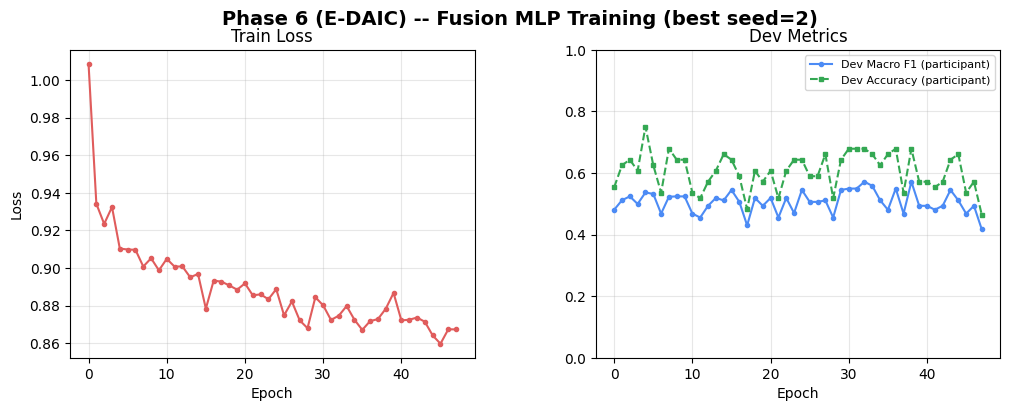

Plot saved to phase6_outputs/phase6_training_curves.png


In [11]:
print("SECTION 8: TRAINING CURVES")

best_history = seed_histories[best_seed_idx]

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(1, 2, wspace=0.3)
fig.suptitle(f"Phase 6 (E-DAIC) -- Fusion MLP Training (best seed={best_seed_idx})", fontsize=14, fontweight="bold")

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(best_history["epoch"], best_history["train_loss"], "o-", color="#e05c5c", markersize=3)
ax1.set_title("Train Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(best_history["epoch"], best_history["dev_macro_f1"], "o-", color="#4c8bf5", markersize=3, label="Dev Macro F1 (participant)")
ax2.plot(best_history["epoch"], best_history["dev_accuracy"], "s--", color="#34a853", markersize=3, label="Dev Accuracy (participant)")
ax2.set_title("Dev Metrics"); ax2.set_xlabel("Epoch"); ax2.set_ylim(0, 1); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.savefig(os.path.join(OUTPUT_DIR, "phase6_training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to phase6_outputs/phase6_training_curves.png")

In [10]:
print("SECTION 9: SAVE RESULTS AND PACKAGE FOR DOWNLOAD")

torch.save({
    "model_state_dict": seed_models[best_seed_idx].state_dict(),
    "seed": best_seed_idx,
    "dev_macro_f1": seed_dev_f1s[best_seed_idx],
    "test_metrics": fused_metrics,
    "granularity": "trained_on_segments_evaluated_on_participants",
}, os.path.join(OUTPUT_DIR, "fusion_mlp_checkpoint.pt"))

with open(os.path.join(OUTPUT_DIR, "phase6_comprehensive_results.txt"), "w") as f:
    f.write("PHASE 6 (E-DAIC, trained on segments, evaluated on participants)\n\n")
    f.write("\n\n".join(report_lines))
    f.write("\n\nFINAL depressed_prob SOURCE FOR DEPLOYMENT: " + final_depression_source + "\n")

print("Saved fusion_mlp_checkpoint.pt and phase6_comprehensive_results.txt")

import shutil
from IPython.display import FileLink, display

zip_path = "/kaggle/working/phase6_outputs"
shutil.make_archive(zip_path, "zip", OUTPUT_DIR)
zip_full_path = zip_path + ".zip"
size_mb = os.path.getsize(zip_full_path) / (1024 * 1024)
print(f"\nZipped Phase 6 outputs to: {zip_full_path} ({size_mb:.2f} MB)")
display(FileLink(zip_full_path))

print("\nAll done. Download from the Output tab on Kaggle.")
print("\nFinal system output format:")
print("  condition_probs (5) -- from Phase 4 Head 1, unchanged")
print("  cause_probs (6)     -- from Phase 4 Head 2, unchanged")
print(f"  depressed_prob      -- from the '{final_depression_source}' model (this notebook's decision)")
print("\nAt inference time on a NEW participant: extract segment embeddings the same way")
print("Phase 5 did, run through the deployed model, then average segment probabilities")
print("to get one depressed_prob per participant -- do not report a single segment's prediction alone.")

SECTION 10: SAVE RESULTS AND PACKAGE FOR DOWNLOAD
Saved fusion_mlp_checkpoint.pt and phase6_comprehensive_results.txt

Zipped Phase 6 outputs to: /kaggle/working/phase6_outputs.zip (0.13 MB)


/kaggle/working/phase6_outputs.zip


All done. Download from the Output tab on Kaggle.

Final system output format:
  condition_probs (5) -- from Phase 4 Head 1, unchanged
  cause_probs (6)     -- from Phase 4 Head 2, unchanged
  depressed_prob      -- from the 'text' model (this notebook's decision)

At inference time on a NEW participant: extract segment embeddings the same way
Phase 5 did, run through the deployed model, then average segment probabilities
to get one depressed_prob per participant -- do not report a single segment's prediction alone.
